In [1]:
from google.colab import files
uploaded = files.upload()

Saving AChE_Bioactivity_data_2.csv to AChE_Bioactivity_data_2.csv


In [2]:
!pip install pandas matplotlib seaborn rdkit scikit-learn tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.9/34.9 MB 56.9 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

df = pd.read_csv("AChE_Bioactivity_data_2.csv")
df = df[['canonical_smiles', 'standard_value']].dropna()
df.drop_duplicates(inplace=True)
df = df[(df['standard_value'] > 0) & (df['standard_value'] < 1_000_000)]


df['activity_class'] = df['standard_value'].apply(lambda x: 1 if x <= 1000 else 0)


def smiles_to_ecfp(smiles, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits)
        arr = np.zeros((nBits,), dtype=int)
        DataStructs.ConvertToNumpyArray(fp, arr)
        return arr
    else:
        return np.zeros((nBits,))

X = np.array(df['canonical_smiles'].apply(smiles_to_ecfp).tolist())
y = df['activity_class'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


model = Sequential([
    Dense(512, input_shape=(X.shape[1],), activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

y_pred_probs = model.predict(X_test).flatten()
y_pred_class = (y_pred_probs >= 0.5).astype(int)

Streaming output truncated to the last 5000 lines.
[11:43:09] DEPRECATION WARNING: please use MorganGenerator
[11:43:09] DEPRECATION WARNING: please use MorganGenerator
[11:43:09] DEPRECATION WARNING: please use MorganGenerator
[11:43:09] DEPRECATION WARNING: please use MorganGenerator
[11:43:09] DEPRECATION WARNING: please use MorganGenerator
[11:43:09] DEPRECATION WARNING: please use MorganGenerator
[11:43:09] DEPRECATION WARNING: please use MorganGenerator
[11:43:09] DEPRECATION WARNING: please use MorganGenerator
[11:43:09] DEPRECATION WARNING: please use MorganGenerator
[11:43:09] DEPRECATION WARNING: please use MorganGenerator
[11:43:09] DEPRECATION WARNING: please use MorganGenerator
[11:43:09] DEPRECATION WARNING: please use MorganGenerator
[11:43:09] DEPRECATION WARNING: please use MorganGenerator
[11:43:09] DEPRECATION WARNING: please use MorganGenerator
[11:43:09] DEPRECATION WARNING: please use MorganGenerator
[11:43:09] DEPRECATION WARNING: please use MorganGenerator
[11:4

Epoch 1/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7014 - loss: 0.5652 - val_accuracy: 0.7642 - val_loss: 0.4817
Epoch 2/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8256 - loss: 0.4009 - val_accuracy: 0.7868 - val_loss: 0.4467
Epoch 3/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8428 - loss: 0.3441 - val_accuracy: 0.7902 - val_loss: 0.4622
Epoch 4/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8663 - loss: 0.3049 - val_accuracy: 0.7965 - val_loss: 0.4916
Epoch 5/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8806 - loss: 0.2723 - val_accuracy: 0.7954 - val_loss: 0.4766
Epoch 6/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8896 - loss: 0.2490 - val_accuracy: 0.7868 - val_loss: 0.5238
Epoch 7/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8934 - loss: 0.2343 - val_accuracy: 0.7891 - val_loss: 0.5588
Epoch 8/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8887 - loss: 0.2328 - 

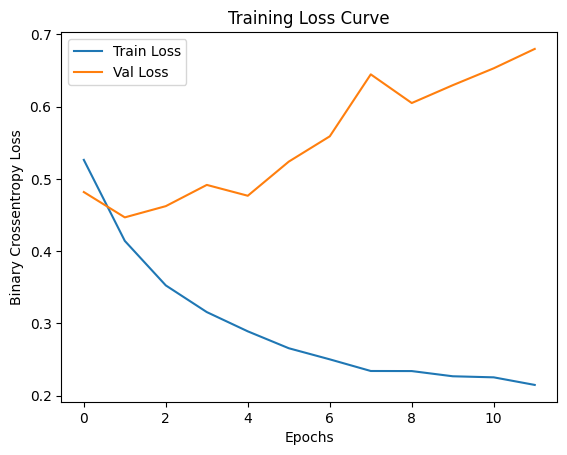

In [4]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()
plt.show()

In [5]:
print("Accuracy:", accuracy_score(y_test, y_pred_class))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_probs))
print("\nClassification Report:\n", classification_report(y_test, y_pred_class))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_class))

Accuracy: 0.7876588021778584
ROC-AUC: 0.8558486840075288

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.67      0.70       819
           1       0.82      0.86      0.84      1385

    accuracy                           0.79      2204
   macro avg       0.77      0.76      0.77      2204
weighted avg       0.79      0.79      0.79      2204

Confusion Matrix:
 [[ 550  269]
 [ 199 1186]]


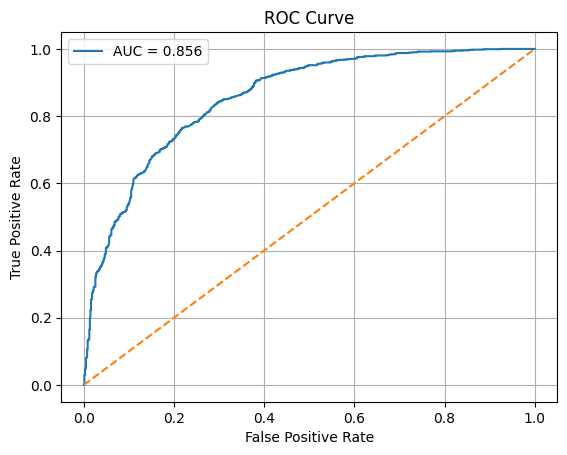

In [6]:
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_probs):.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

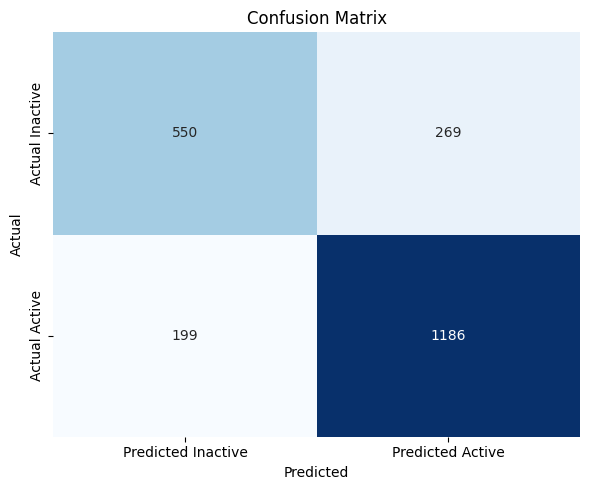

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Get confusion matrix
cm = confusion_matrix(y_test, y_pred_class)

# Plot it
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Inactive', 'Predicted Active'],
            yticklabels=['Actual Inactive', 'Actual Active'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()